# Exploratory: m/z-guided retention time alignment

The core idea: fatty acid EI fragmentation patterns (m/z spectra) are physically fixed — they don't change between labs. We can use the m/z spectrum at each chromatogram peak as a fingerprint to identify which compound is eluting, then match peaks across samples to recover the retention time warp.

**Data:** `fish_oil/chroma/*.npz` — each sample is a `(200, 1000)` float32 array.
- Axis 0: 200 time bins covering a 45-min run (~0.225 min/bin)
- Axis 1: 1000 m/z bins (Da), populated in the range ~50–543 Da

**Known landmarks from saliency analysis:**
- ~16 min (bin ~71): palmitic acid (16:0)
- ~26 min (bin ~116): oleic acid (18:1n-9)
- ~40 min (bin ~178): DHA (22:6n-3)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.signal import find_peaks
from sklearn.metrics.pairwise import cosine_similarity

DATA_DIR = Path('../data/fish_oil')
CHROMA_DIR = DATA_DIR / 'chroma'

# 45-min run, 200 time bins
RUN_DURATION_MIN = 45.0
N_TIME_BINS = 200
MIN_PER_BIN = RUN_DURATION_MIN / N_TIME_BINS  # 0.225 min/bin
TIME_AXIS = np.linspace(0, RUN_DURATION_MIN, N_TIME_BINS)

# Known fatty acid landmarks (minutes)
LANDMARKS = {
    'Palmitic (16:0)':   16.0,
    'Oleic (18:1n-9)':   26.0,
    'DHA (22:6n-3)':     40.0,
}

npz_paths = sorted(CHROMA_DIR.glob('*.npz'))
sample_ids = [p.stem for p in npz_paths]
print(f'{len(npz_paths)} samples found')
from scipy.optimize import linear_sum_assignment


103 samples found


## 1. Visualise a single sample

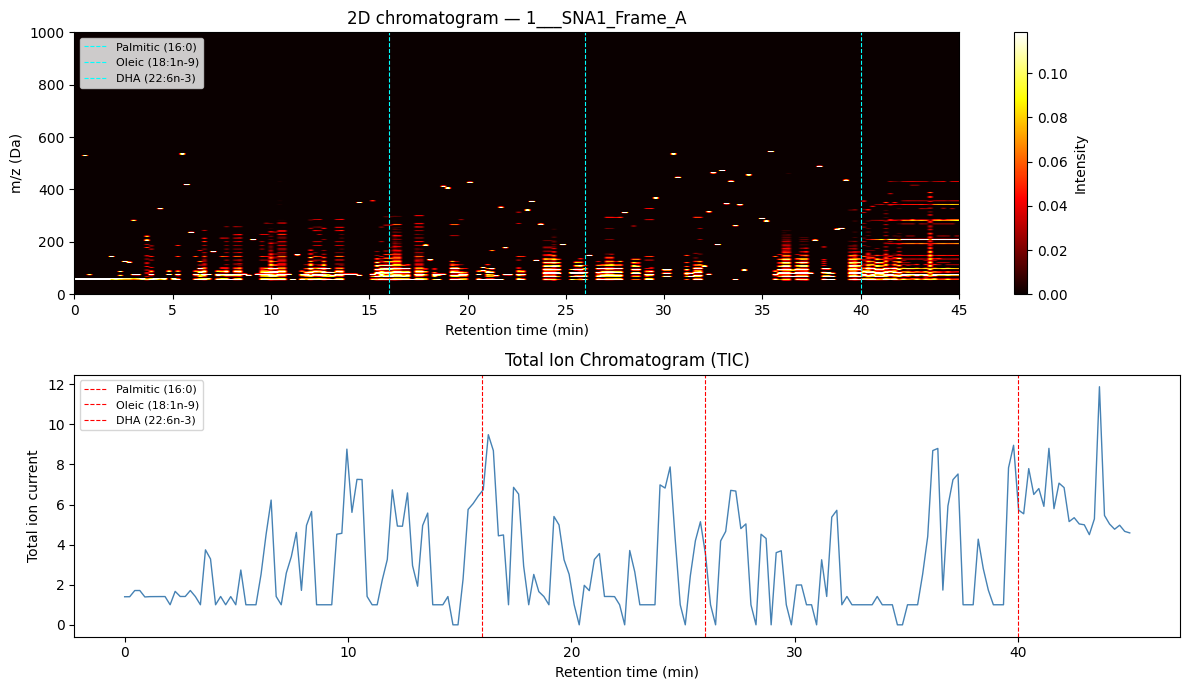

In [2]:
sample = np.load(npz_paths[0])['chroma']  # (200, 1000)
tic = sample.sum(axis=1)                  # sum over m/z → (200,) total ion chromatogram

fig, axes = plt.subplots(2, 1, figsize=(12, 7))

# 2D heatmap
ax = axes[0]
im = ax.imshow(
    sample.T,           # (1000 m/z × 200 time) so m/z on y-axis
    aspect='auto',
    origin='lower',
    extent=[0, RUN_DURATION_MIN, 0, 1000],
    cmap='hot',
    vmax=np.percentile(sample, 99),
)
ax.set_xlabel('Retention time (min)')
ax.set_ylabel('m/z (Da)')
ax.set_title(f'2D chromatogram — {sample_ids[0]}')
for name, rt in LANDMARKS.items():
    ax.axvline(rt, color='cyan', lw=0.8, ls='--', label=name)
ax.legend(fontsize=8, loc='upper left')
plt.colorbar(im, ax=ax, label='Intensity')

# TIC
ax = axes[1]
ax.plot(TIME_AXIS, tic, color='steelblue', lw=1)
for name, rt in LANDMARKS.items():
    ax.axvline(rt, color='red', lw=0.8, ls='--', label=name)
ax.set_xlabel('Retention time (min)')
ax.set_ylabel('Total ion current')
ax.set_title('Total Ion Chromatogram (TIC)')
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

## 2. Peak detection on the TIC

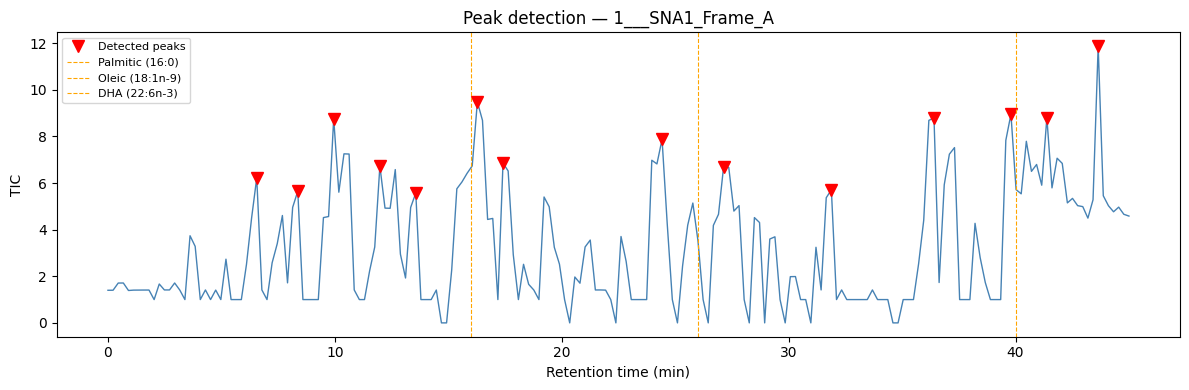

Detected 14 peaks at retention times (min):
[ 6.56  8.37  9.95 11.98 13.57 16.28 17.41 24.42 27.14 31.88 36.41 39.8
 41.38 43.64]


In [3]:
def detect_peaks(chroma, height_percentile=80, min_distance_bins=5, n_peaks=15):
    """Return indices of the top-N peaks in the TIC."""
    tic = chroma.sum(axis=1)
    threshold = np.percentile(tic, height_percentile)
    peaks, props = find_peaks(tic, height=threshold, distance=min_distance_bins)
    # Keep top-N by height
    if len(peaks) > n_peaks:
        top = np.argsort(props['peak_heights'])[-n_peaks:]
        peaks = peaks[top]
    return np.sort(peaks)


peaks = detect_peaks(sample)
tic = sample.sum(axis=1)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(TIME_AXIS, tic, color='steelblue', lw=1)
ax.plot(TIME_AXIS[peaks], tic[peaks], 'rv', ms=8, label='Detected peaks')
for name, rt in LANDMARKS.items():
    ax.axvline(rt, color='orange', lw=0.8, ls='--', label=name)
ax.set_xlabel('Retention time (min)')
ax.set_ylabel('TIC')
ax.set_title(f'Peak detection — {sample_ids[0]}')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

print(f'Detected {len(peaks)} peaks at retention times (min):')
print(np.round(TIME_AXIS[peaks], 2))

## 3. M/z fingerprints at each peak

The m/z spectrum at a peak time bin is the EI fragmentation pattern of the eluting compound. We L2-normalise so cosine similarity is concentration-invariant.

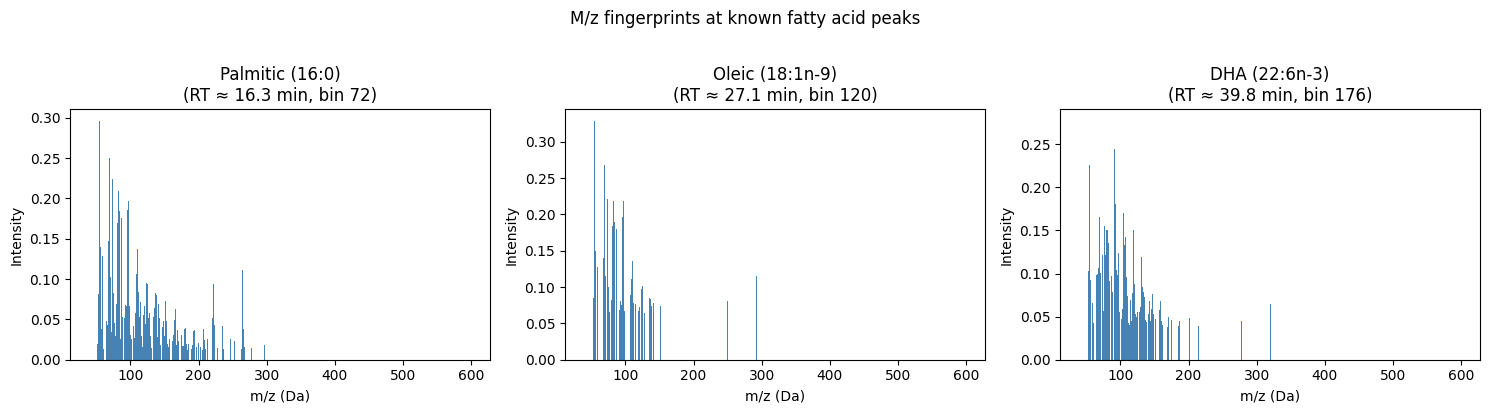

In [4]:
def extract_fingerprints(chroma, peak_indices):
    """Return L2-normalised m/z spectra at each peak. Shape: (n_peaks, 1000)."""
    spectra = chroma[peak_indices, :]  # (n_peaks, 1000)
    norms = np.linalg.norm(spectra, axis=1, keepdims=True)
    norms = np.where(norms == 0, 1.0, norms)  # avoid division by zero
    return spectra / norms


fps = extract_fingerprints(sample, peaks)

# Plot m/z fingerprints for the known landmark peaks
landmark_bins = {name: int(rt / MIN_PER_BIN) for name, rt in LANDMARKS.items()}
# Find the detected peak closest to each landmark
landmark_peaks = {}
for name, bin_idx in landmark_bins.items():
    closest = peaks[np.argmin(np.abs(peaks - bin_idx))]
    landmark_peaks[name] = closest

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
mz_axis = np.arange(1000)
for ax, (name, peak_bin) in zip(axes, landmark_peaks.items()):
    spectrum = sample[peak_bin, :]
    ax.bar(mz_axis[40:600], spectrum[40:600], width=1, color='steelblue')
    ax.set_xlabel('m/z (Da)')
    ax.set_ylabel('Intensity')
    ax.set_title(f'{name}\n(RT ≈ {TIME_AXIS[peak_bin]:.1f} min, bin {peak_bin})')
plt.suptitle('M/z fingerprints at known fatty acid peaks', y=1.02)
plt.tight_layout()
plt.show()

## 4. Retention time drift across samples

Load all samples, detect peaks in each, and record the retention time of the peak with the highest cosine similarity to a reference fingerprint. If retention times differ across samples, the warp is non-trivial.

In [5]:
# Load all samples
all_chromas = [np.load(p)['chroma'] for p in npz_paths]

# Use the first sample as reference
ref_chroma = all_chromas[0]
ref_peaks = detect_peaks(ref_chroma)
ref_fps = extract_fingerprints(ref_chroma, ref_peaks)  # (n_ref_peaks, 1000)

# For each sample: Hungarian one-to-one matching to reference peaks
results = []
for sid, chroma in zip(sample_ids, all_chromas):
    peaks_i = detect_peaks(chroma)
    fps_i = extract_fingerprints(chroma, peaks_i)      # (n_peaks, 1000)
    sim = cosine_similarity(fps_i, ref_fps)            # (n_q, n_ref)
    row_ind, col_ind = linear_sum_assignment(-sim)     # one-to-one
    matched_sim = sim[row_ind, col_ind]
    # Re-index so ref peaks are the columns
    matched_rt = np.full(len(ref_peaks), np.nan)
    best_sim_arr = np.zeros(len(ref_peaks))
    for r, c, s in zip(row_ind, col_ind, matched_sim):
        matched_rt[c] = TIME_AXIS[peaks_i[r]]
        best_sim_arr[c] = s
    results.append({
        'sample': sid,
        'matched_rt': matched_rt,
        'ref_rt': TIME_AXIS[ref_peaks],
        'similarity': best_sim_arr,
    })

print(f'Processed {len(results)} samples')
print(f'Reference peaks at (min): {np.round(TIME_AXIS[ref_peaks], 2)}')


Processed 103 samples
Reference peaks at (min): [ 6.56  8.37  9.95 11.98 13.57 16.28 17.41 24.42 27.14 31.88 36.41 39.8
 41.38 43.64]


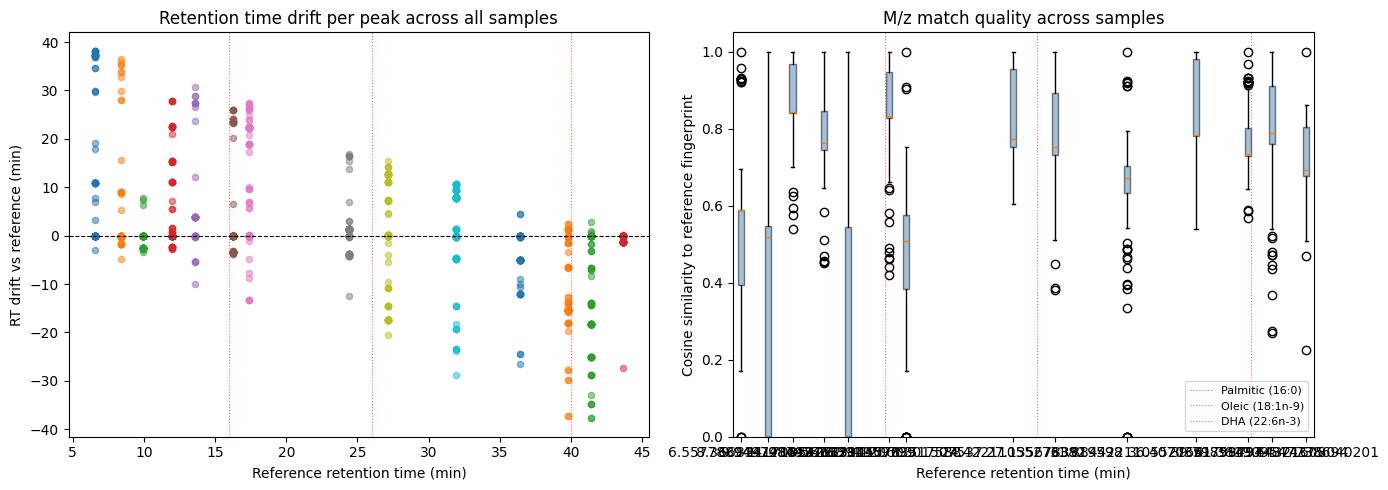

In [6]:
# Plot RT drift: for each reference peak, show matched RT across all samples
n_ref_peaks = len(ref_peaks)
matched_rts = np.array([r['matched_rt'] for r in results])   # (n_samples, n_ref_peaks)
similarities = np.array([r['similarity'] for r in results])  # (n_samples, n_ref_peaks)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: RT drift per reference peak
ax = axes[0]
ref_rts = TIME_AXIS[ref_peaks]
for i in range(n_ref_peaks):
    drift = matched_rts[:, i] - ref_rts[i]
    ax.scatter([ref_rts[i]] * len(drift), drift, alpha=0.5, s=20)
ax.axhline(0, color='k', lw=0.8, ls='--')
ax.set_xlabel('Reference retention time (min)')
ax.set_ylabel('RT drift vs reference (min)')
ax.set_title('Retention time drift per peak across all samples')

# Right: cosine similarity of best matches
ax = axes[1]
ax.boxplot(similarities, positions=ref_rts, widths=0.4,
           patch_artist=True, boxprops=dict(facecolor='steelblue', alpha=0.5))
ax.set_xlabel('Reference retention time (min)')
ax.set_ylabel('Cosine similarity to reference fingerprint')
ax.set_title('M/z match quality across samples')
ax.set_ylim(0, 1.05)

for name, rt in LANDMARKS.items():
    axes[0].axvline(rt, color='red', lw=0.8, ls=':', alpha=0.6)
    axes[1].axvline(rt, color='red', lw=0.8, ls=':', alpha=0.6, label=name)
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

## 5. Pairwise RT alignment using matched anchors

For a pair of samples, use cosine-matched peaks as anchor points and fit a piecewise-linear warp. This is the classical COW idea, but anchored by m/z fingerprints rather than TIC correlation.

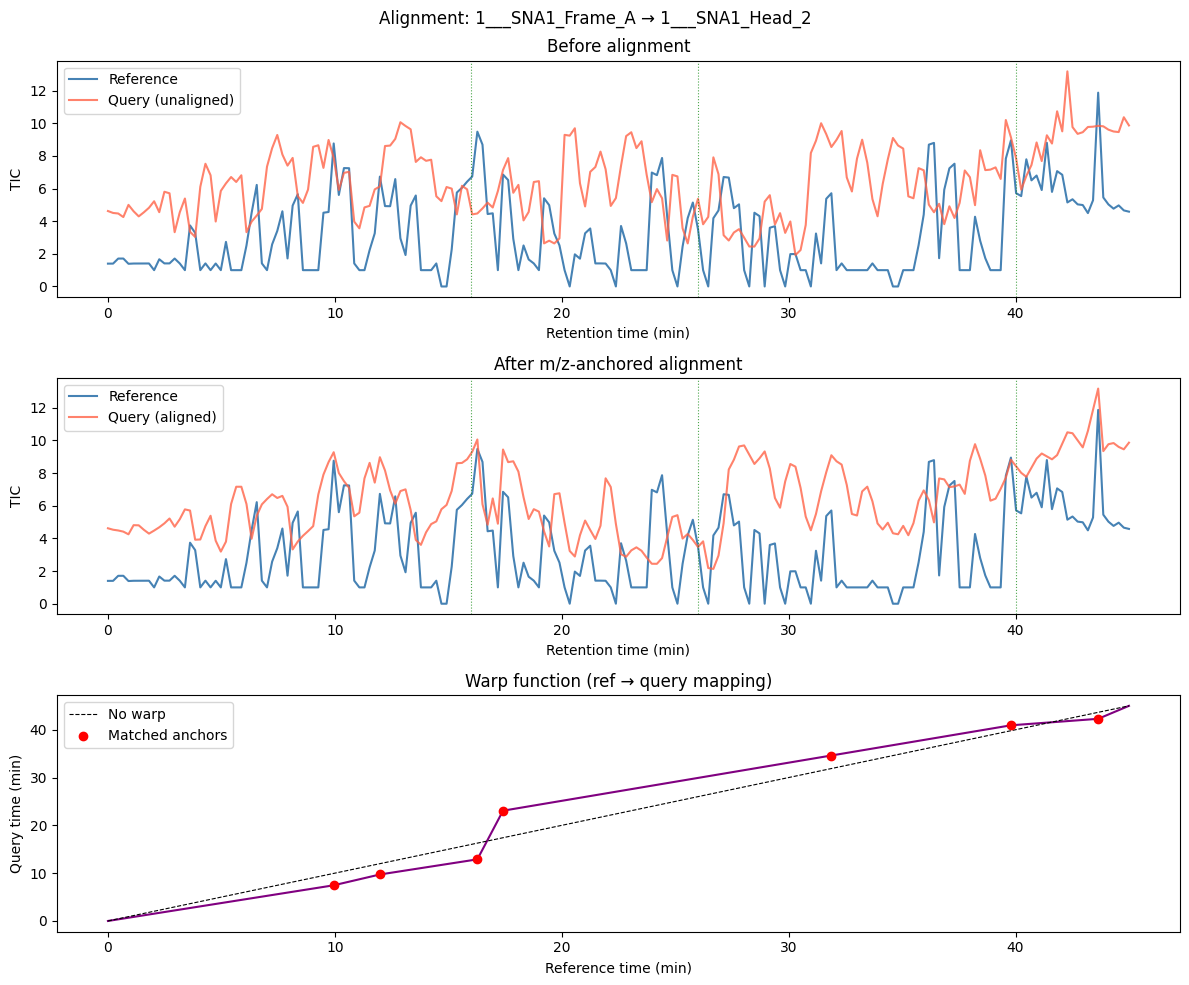

Used 7 anchor pairs
Ref anchors (min):   [ 9.95 11.98 16.28 17.41 31.88 39.8  43.64]
Query anchors (min): [ 7.46  9.72 12.89 23.07 34.6  40.93 42.29]
Drift (min):         [-2.49 -2.26 -3.39  5.65  2.71  1.13 -1.36]


In [7]:
from scipy.interpolate import interp1d
from scipy.optimize import linear_sum_assignment

def align_to_reference(query_chroma, ref_chroma, sim_threshold=0.6, max_drift_min=6.0):
    """
    Warp query TIC onto reference time axis using m/z-matched peak anchors.
    - One-to-one Hungarian matching constrained to a time window (max_drift_min).
    - Monotonicity enforced after matching.
    """
    ref_peaks = detect_peaks(ref_chroma)
    q_peaks = detect_peaks(query_chroma)

    ref_fps = extract_fingerprints(ref_chroma, ref_peaks)
    q_fps = extract_fingerprints(query_chroma, q_peaks)

    sim = cosine_similarity(q_fps, ref_fps)  # (n_q, n_ref)

    # Mask out pairs that exceed the maximum allowed time drift
    ref_times = TIME_AXIS[ref_peaks]  # (n_ref,)
    q_times = TIME_AXIS[q_peaks]      # (n_q,)
    drift_mask = np.abs(q_times[:, None] - ref_times[None, :]) > max_drift_min  # (n_q, n_ref)
    sim_constrained = sim.copy()
    sim_constrained[drift_mask] = -1.0  # effectively forbidden

    # One-to-one bipartite matching
    row_ind, col_ind = linear_sum_assignment(-sim_constrained)
    matched_sim = sim[row_ind, col_ind]

    # Filter by similarity threshold and window
    keep = (matched_sim >= sim_threshold) & (~drift_mask[row_ind, col_ind])
    row_ind, col_ind = row_ind[keep], col_ind[keep]

    if len(row_ind) < 2:
        return query_chroma.sum(axis=1), None, np.array([]), np.array([])

    # Sort by reference peak order
    order = np.argsort(col_ind)
    row_ind, col_ind = row_ind[order], col_ind[order]

    ref_anchors = TIME_AXIS[ref_peaks[col_ind]]
    q_anchors = TIME_AXIS[q_peaks[row_ind]]

    # Enforce monotonicity (drop any anchor where query goes backwards)
    monotone = [0]
    for i in range(1, len(q_anchors)):
        if q_anchors[i] > q_anchors[monotone[-1]]:
            monotone.append(i)
    ref_anchors = ref_anchors[monotone]
    q_anchors = q_anchors[monotone]

    # Boundary anchors
    ref_full = np.concatenate([[0], ref_anchors, [RUN_DURATION_MIN]])
    q_full = np.concatenate([[0], q_anchors, [RUN_DURATION_MIN]])

    warp_fn = interp1d(ref_full, q_full, kind='linear',
                       bounds_error=False, fill_value='extrapolate')
    query_times_on_ref_grid = warp_fn(TIME_AXIS)
    query_tic = query_chroma.sum(axis=1)
    resample_fn = interp1d(TIME_AXIS, query_tic, bounds_error=False, fill_value=0.0)
    warped_tic = resample_fn(query_times_on_ref_grid)

    return warped_tic, warp_fn, ref_anchors, q_anchors


# Align sample 5 to sample 0
ref = all_chromas[0]
query = all_chromas[5]

ref_tic = ref.sum(axis=1)
query_tic = query.sum(axis=1)
warped_tic, warp_fn, ref_anchors, q_anchors = align_to_reference(query, ref)

fig, axes = plt.subplots(3, 1, figsize=(12, 10))

axes[0].plot(TIME_AXIS, ref_tic, label='Reference', color='steelblue')
axes[0].plot(TIME_AXIS, query_tic, label='Query (unaligned)', color='tomato', alpha=0.8)
axes[0].set_title('Before alignment')
axes[0].set_ylabel('TIC')
axes[0].legend()

axes[1].plot(TIME_AXIS, ref_tic, label='Reference', color='steelblue')
axes[1].plot(TIME_AXIS, warped_tic, label='Query (aligned)', color='tomato', alpha=0.8)
axes[1].set_title('After m/z-anchored alignment')
axes[1].set_ylabel('TIC')
axes[1].legend()

if warp_fn is not None:
    axes[2].plot(TIME_AXIS, warp_fn(TIME_AXIS), color='purple', lw=1.5)
    axes[2].plot([0, RUN_DURATION_MIN], [0, RUN_DURATION_MIN], 'k--', lw=0.8, label='No warp')
    axes[2].scatter(ref_anchors, q_anchors, color='red', zorder=5, label='Matched anchors')
    axes[2].set_xlabel('Reference time (min)')
    axes[2].set_ylabel('Query time (min)')
    axes[2].set_title('Warp function (ref \u2192 query mapping)')
    axes[2].legend()

for ax in axes[:2]:
    ax.set_xlabel('Retention time (min)')
    for name, rt in LANDMARKS.items():
        ax.axvline(rt, color='green', lw=0.8, ls=':', alpha=0.7)

plt.suptitle(f'Alignment: {sample_ids[0]} \u2192 {sample_ids[5]}', fontsize=12)
plt.tight_layout()
plt.show()

print(f'Used {len(ref_anchors)} anchor pairs')
print(f'Ref anchors (min):   {np.round(ref_anchors, 2)}')
print(f'Query anchors (min): {np.round(q_anchors, 2)}')
print(f'Drift (min):         {np.round(q_anchors - ref_anchors, 2)}')


## 6. Alignment quality: cross-sample TIC correlation before vs after

A simple global metric: Pearson correlation of TICs between all pairs, before and after alignment.

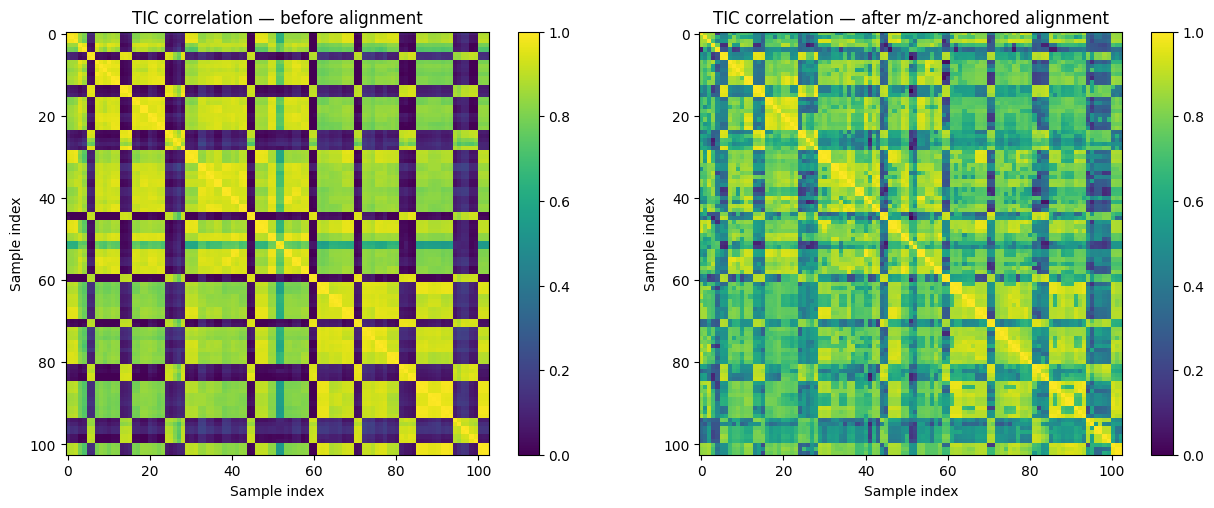

Mean off-diagonal TIC correlation:
  Before: 0.564
  After:  0.664


In [8]:
n = len(all_chromas)
corr_before = np.zeros((n, n))
corr_after = np.zeros((n, n))

tics = [c.sum(axis=1) for c in all_chromas]

for i in range(n):
    for j in range(n):
        corr_before[i, j] = np.corrcoef(tics[i], tics[j])[0, 1]
        warped, _, _, _ = align_to_reference(all_chromas[j], all_chromas[i])
        corr_after[i, j] = np.corrcoef(tics[i], warped)[0, 1]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, mat, title in zip(axes,
                           [corr_before, corr_after],
                           ['TIC correlation — before alignment',
                            'TIC correlation — after m/z-anchored alignment']):
    im = ax.imshow(mat, vmin=0, vmax=1, cmap='viridis')
    ax.set_title(title)
    ax.set_xlabel('Sample index')
    ax.set_ylabel('Sample index')
    plt.colorbar(im, ax=ax)

plt.tight_layout()
plt.show()

# Summarise off-diagonal improvement
mask = ~np.eye(n, dtype=bool)
print(f'Mean off-diagonal TIC correlation:')
print(f'  Before: {corr_before[mask].mean():.3f}')
print(f'  After:  {corr_after[mask].mean():.3f}')

## 7. Cross-study alignment: fish_oil ↔ mtbls288

Both are FAME GC-MS datasets but collected independently (different samples, likely different instruments). mtbls288 has much higher inter-sample RT variability (~2–3 min std vs ~0 min for fish_oil). Here we test whether m/z fingerprinting can align a sample from one study onto the other.

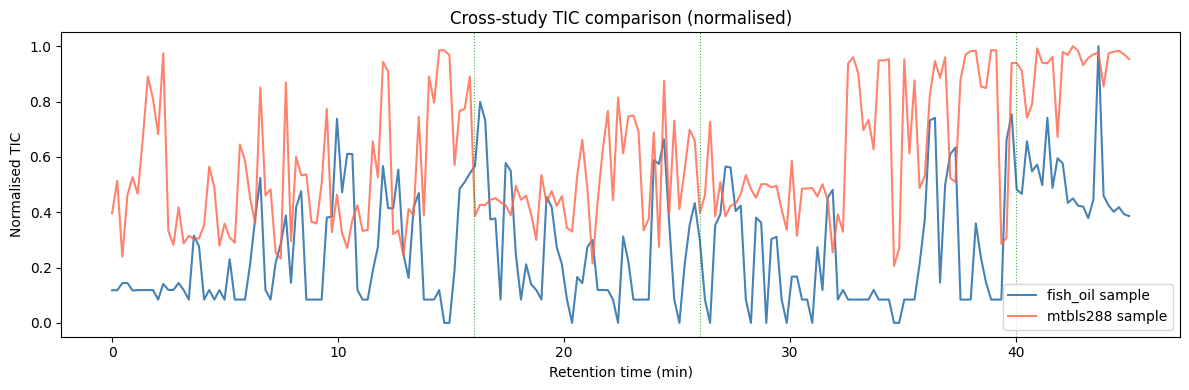

In [9]:
from pathlib import Path

FISH_DIR  = Path('../data/fish_oil/chroma')
M288_DIR  = Path('../data/mtbls288/chroma')

fish_paths = sorted(FISH_DIR.glob('*.npz'))
m288_paths = sorted(M288_DIR.glob('*.npz'))

# Load one representative sample from each study
fish_sample = np.load(fish_paths[0])['chroma']
m288_sample = np.load(m288_paths[9])['chroma']   # sample 10 has spread-out peaks

fish_tic = fish_sample.sum(axis=1)
m288_tic = m288_sample.sum(axis=1)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(TIME_AXIS, fish_tic / fish_tic.max(), label='fish_oil sample', color='steelblue')
ax.plot(TIME_AXIS, m288_tic / m288_tic.max(), label='mtbls288 sample', color='tomato', alpha=0.8)
for name, rt in LANDMARKS.items():
    ax.axvline(rt, color='green', lw=0.8, ls=':', alpha=0.7)
ax.set_xlabel('Retention time (min)')
ax.set_ylabel('Normalised TIC')
ax.set_title('Cross-study TIC comparison (normalised)')
ax.legend()
plt.tight_layout()
plt.show()


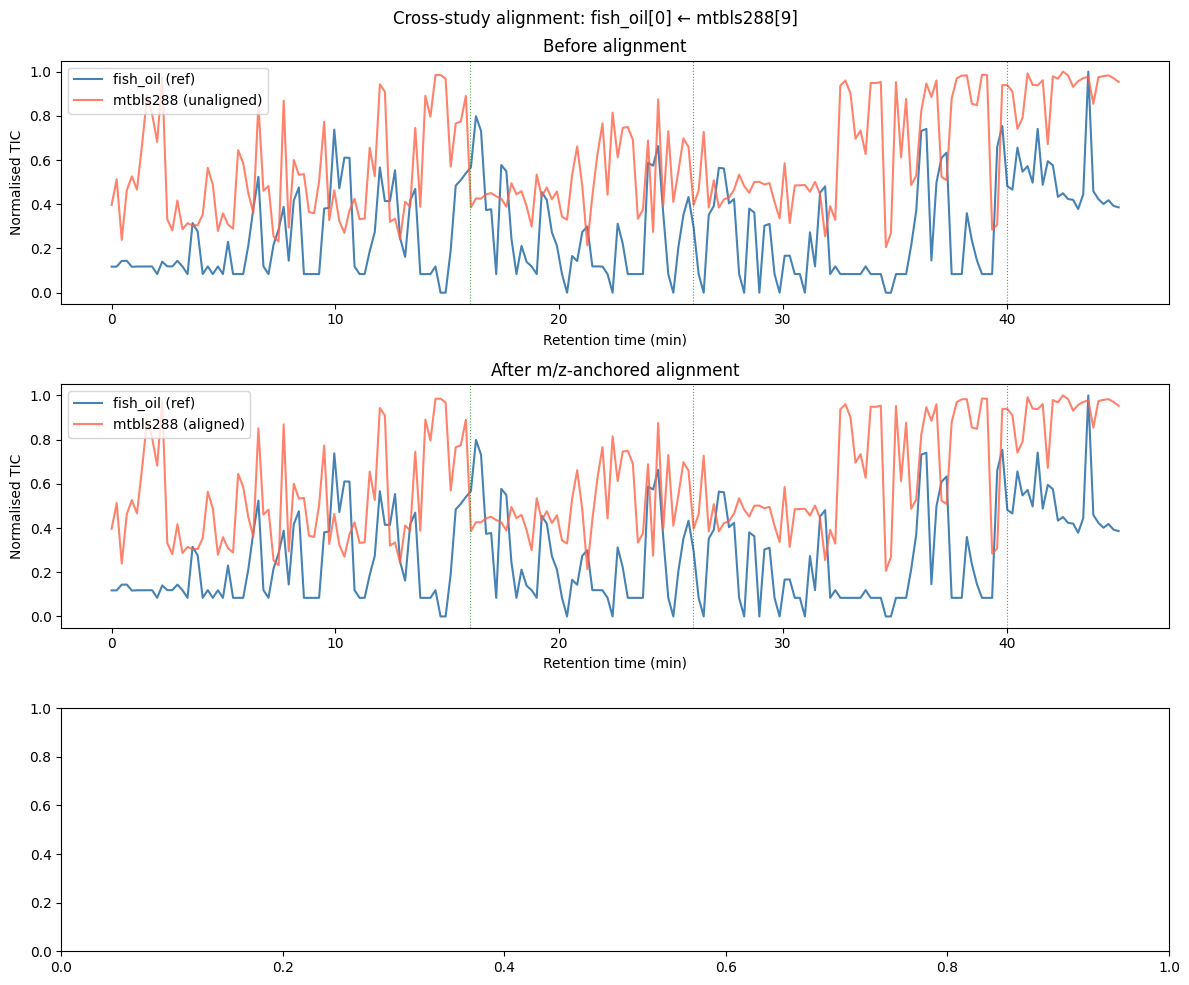

Cross-study TIC correlation:
  Before: 0.170
  After:  0.170
Drift at anchors (min): []


In [10]:
# Cross-study alignment: warp mtbls288 onto fish_oil reference
warped, warp_fn, ref_anch, q_anch = align_to_reference(m288_sample, fish_sample)

fig, axes = plt.subplots(3, 1, figsize=(12, 10))

axes[0].plot(TIME_AXIS, fish_tic / fish_tic.max(), label='fish_oil (ref)', color='steelblue')
axes[0].plot(TIME_AXIS, m288_tic / m288_tic.max(), label='mtbls288 (unaligned)', color='tomato', alpha=0.8)
axes[0].set_title('Before alignment'); axes[0].set_ylabel('Normalised TIC'); axes[0].legend()

axes[1].plot(TIME_AXIS, fish_tic / fish_tic.max(), label='fish_oil (ref)', color='steelblue')
axes[1].plot(TIME_AXIS, warped / warped.max(), label='mtbls288 (aligned)', color='tomato', alpha=0.8)
axes[1].set_title('After m/z-anchored alignment'); axes[1].set_ylabel('Normalised TIC'); axes[1].legend()

if warp_fn is not None:
    axes[2].plot(TIME_AXIS, warp_fn(TIME_AXIS), color='purple', lw=1.5)
    axes[2].plot([0, RUN_DURATION_MIN], [0, RUN_DURATION_MIN], 'k--', lw=0.8, label='No warp')
    axes[2].scatter(ref_anch, q_anch, color='red', zorder=5, label='Matched anchors')
    axes[2].set_xlabel('Reference time (min)'); axes[2].set_ylabel('Query time (min)')
    axes[2].set_title('Warp function'); axes[2].legend()

for ax in axes[:2]:
    ax.set_xlabel('Retention time (min)')
    for name, rt in LANDMARKS.items():
        ax.axvline(rt, color='green', lw=0.8, ls=':', alpha=0.7)

plt.suptitle(f'Cross-study alignment: fish_oil[0] ← mtbls288[9]', fontsize=12)
plt.tight_layout()
plt.show()

corr_before = np.corrcoef(fish_tic, m288_tic)[0, 1]
corr_after  = np.corrcoef(fish_tic, warped)[0, 1]
print(f'Cross-study TIC correlation:')
print(f'  Before: {corr_before:.3f}')
print(f'  After:  {corr_after:.3f}')
print(f'Drift at anchors (min): {np.round(q_anch - ref_anch, 2)}')


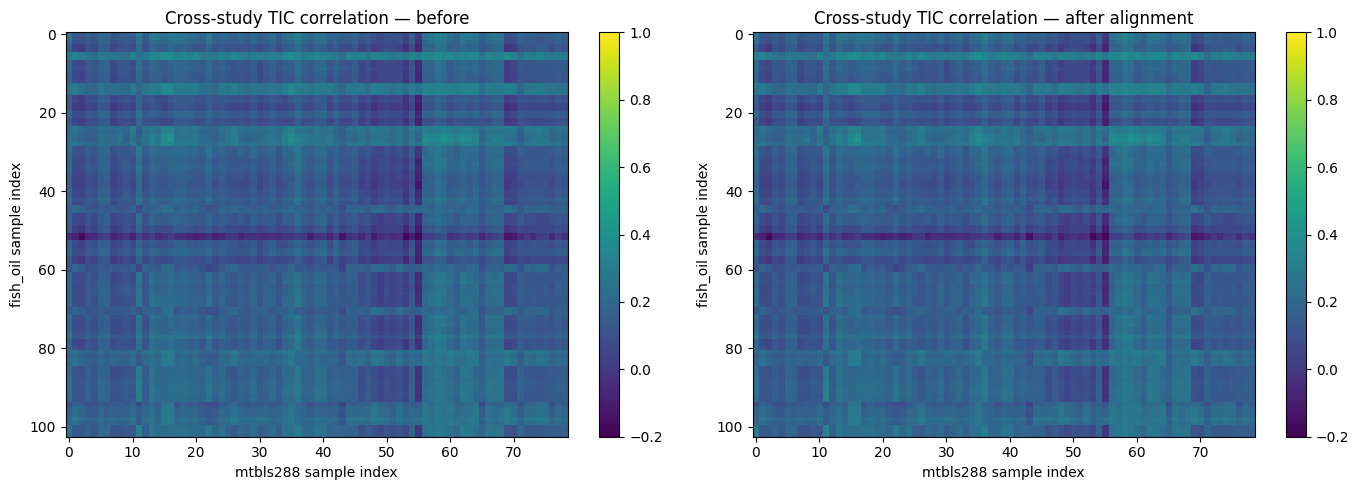

Mean cross-study TIC correlation:
  Before: 0.161
  After:  0.161
  Improvement: +0.000


In [11]:
# Full cross-study correlation matrix: N_fish × N_m288 pairs
n_fish = len(fish_paths)
n_m288 = len(m288_paths)

cross_before = np.zeros((n_fish, n_m288))
cross_after  = np.zeros((n_fish, n_m288))

all_fish  = [np.load(p)['chroma'] for p in fish_paths]
all_m288  = [np.load(p)['chroma'] for p in m288_paths]
fish_tics = [c.sum(axis=1) for c in all_fish]
m288_tics = [c.sum(axis=1) for c in all_m288]

for i, (fc, ft) in enumerate(zip(all_fish, fish_tics)):
    for j, (mc, mt) in enumerate(zip(all_m288, m288_tics)):
        cross_before[i, j] = np.corrcoef(ft, mt)[0, 1]
        warped, _, _, _ = align_to_reference(mc, fc)
        cross_after[i, j]  = np.corrcoef(ft, warped)[0, 1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, mat, title in zip(axes,
                           [cross_before, cross_after],
                           ['Cross-study TIC correlation — before',
                            'Cross-study TIC correlation — after alignment']):
    im = ax.imshow(mat, vmin=-0.2, vmax=1, cmap='viridis', aspect='auto')
    ax.set_xlabel('mtbls288 sample index')
    ax.set_ylabel('fish_oil sample index')
    ax.set_title(title)
    plt.colorbar(im, ax=ax)

plt.tight_layout()
plt.show()

mask = np.ones_like(cross_before, dtype=bool)
print(f'Mean cross-study TIC correlation:')
print(f'  Before: {cross_before.mean():.3f}')
print(f'  After:  {cross_after.mean():.3f}')
print(f'  Improvement: {cross_after.mean() - cross_before.mean():+.3f}')


## 8. Reference library: identify peaks by MoNA m/z fingerprints

Rather than pairwise sample-to-sample matching, we can match each detected peak against a curated library of reference EI-MS spectra. The pretraining data contains 9,553 MoNA spectra with SMILES and InChIKeys. We filter for FAME-like structures (methyl esters of long-chain fatty acids) to build a targeted reference library.

In [12]:
import h5py

SPECTRA_PATH = Path('../data/pretraining/spectra.h5')

with h5py.File(SPECTRA_PATH) as f:
    lib_smiles   = [s.decode() for s in f['smiles'][:]]
    lib_inchikey = [s.decode() for s in f['inchikeys'][:]]
    lib_spectra  = f['spectra'][:]   # (9553, 1000) — already L2-normalised

import re

def is_fame(smi):
    """
    Strict filter for fatty acid methyl esters (FAMEs):
      - Acyclic: no ring-closure digits in SMILES
      - No aromatic atoms
      - No heteroatoms other than O (no N, P, S, halogens)
      - Exactly one ester group
      - Exactly one carbonyl (excludes beta-keto esters)
      - Methyl ester specifically: SMILES ends with C(=O)OC
      - Minimum 16 total carbons (methyl ester of C14+ fatty acid)
    """
    if re.search(r'\d', smi):                                    # ring closures
        return False
    if re.search(r'[cnops]', smi):                                # aromatic atoms
        return False
    if any(x in smi for x in ['N', 'P', 'S', 'F', 'Cl', 'Br', 'I']):
        return False
    if smi.count('C(=O)O') != 1:                                  # exactly one ester
        return False
    if smi.count('(=O)') != 1:                                    # no keto groups
        return False
    if not re.search(r'C\(=O\)OC$', smi):                      # methyl ester only
        return False
    if smi.count('C') < 16:                                       # minimum chain length
        return False
    return True

fame_mask = np.array([is_fame(s) for s in lib_smiles])
fame_spectra  = lib_spectra[fame_mask]
fame_smiles   = [s for s, m in zip(lib_smiles,   fame_mask) if m]
fame_inchikey = [s for s, m in zip(lib_inchikey, fame_mask) if m]

print(f'Total MoNA spectra:  {len(lib_smiles)}')
print(f'FAME spectra (strict): {fame_mask.sum()}')
print()
print('All FAME SMILES:')
for s, ik in zip(fame_smiles, fame_inchikey):
    n_c = s.count('C')
    n_db = s.count('=C')   # approximate double bond count
    print(f'  C={n_c:2d}  db={n_db}  {s}')


Total MoNA spectra:  9553
FAME spectra (strict): 42

All FAME SMILES:
  C=20  db=0  CCCCCCCCCCCCCCCCCCC(=O)OC
  C=19  db=1  CCCCCCC(O)CC=CCCCCCCCC(=O)OC
  C=24  db=0  CCCCCCCCCCCCCCCCCCCCCCC(=O)OC
  C=22  db=0  CCCCCCCCCCCCCCCCCCCCC(=O)OC
  C=21  db=0  CCCCCCCCCCCCCCCCCCCC(=O)OC
  C=18  db=0  CCCCCCCCCCCCCCCCC(=O)OC
  C=19  db=0  CCCCCCCCCCCCCCCCCC(=O)OC
  C=17  db=0  CCCCCCCCCCCCCCCC(=O)OC
  C=16  db=0  CCCCCCCCCCCCCCC(=O)OC
  C=19  db=0  CCCCCCCCCCCCCC(OC(C)=O)CC(=O)OC
  C=17  db=0  CCCCCCCCCCCCCC(O)CC(=O)OC
  C=17  db=1  CCCCCCC([H])=C([H])CCCCCCCC(=O)OC
  C=19  db=1  CCCCCCCCCCCC([H])=C([H])CCCCC(=O)OC
  C=19  db=4  CCC([H])=C([H])CC([H])=C([H])CC([H])=C([H])CC([H])=C([H])CCCCC(=O)OC
  C=19  db=3  CCC([H])=C([H])CC([H])=C([H])CCCCC([H])=C([H])CCCCC(=O)OC
  C=19  db=3  CCC([H])=C([H])CCCCC([H])=C([H])CC([H])=C([H])CCCCC(=O)OC
  C=19  db=3  CCC=CCC=CCC=CCCCCCCCC(=O)OC
  C=19  db=2  CCC([H])=C([H])CC([H])=C([H])CCCCCCCCCCC(=O)OC
  C=19  db=2  CCC([H])=C([H])CCCCC([H])=C([H])CCCCCCCC(=

In [13]:
from sklearn.metrics.pairwise import cosine_similarity as cos_sim

def identify_peaks(chroma, fame_spectra, fame_smiles, fame_inchikey,
                   top_n=5, sim_threshold=0.5):
    """
    For each detected peak, find the best-matching compound in the FAME library.
    Returns a list of dicts with RT, best match SMILES, InChIKey, and similarity.
    """
    peaks = detect_peaks(chroma)
    fps   = extract_fingerprints(chroma, peaks)   # (n_peaks, 1000)
    sims  = cos_sim(fps, fame_spectra)             # (n_peaks, n_fames)

    identifications = []
    for i, (peak_bin, fp) in enumerate(zip(peaks, fps)):
        best_idx = sims[i].argmax()
        best_sim = sims[i, best_idx]
        identifications.append({
            'rt_min':    round(float(TIME_AXIS[peak_bin]), 2),
            'sim':       round(float(best_sim), 3),
            'inchikey':  fame_inchikey[best_idx],
            'smiles':    fame_smiles[best_idx][:60],
            'confident': best_sim >= sim_threshold,
        })
    return identifications


# Run on a fish_oil sample
ids = identify_peaks(fish_sample, fame_spectra, fame_smiles, fame_inchikey)

print(f'Peak identifications for fish_oil sample (against {len(fame_smiles)} FAME references):')
print(f'  {"RT (min)":>8}  {"Sim":>5}  {"Confident":>9}  InChIKey')
for d in ids:
    flag = "✓" if d['confident'] else "✗"
    print(f'  {d["rt_min"]:>8.2f}  {d["sim"]:>5.3f}  {flag:>9}  {d["inchikey"]}')


Peak identifications for fish_oil sample (against 42 FAME references):
  RT (min)    Sim  Confident  InChIKey
      6.56  0.872          ✓  BDXAHSJUDUZLDU-UHFFFAOYSA-N
      8.37  0.862          ✓  BDXAHSJUDUZLDU-UHFFFAOYSA-N
      9.95  0.929          ✓  JEDIPLFNJDRCFD-SREVYHEPSA-N
     11.98  0.862          ✓  JEDIPLFNJDRCFD-SREVYHEPSA-N
     13.57  0.852          ✓  BDXAHSJUDUZLDU-UHFFFAOYSA-N
     16.28  0.941          ✓  JEDIPLFNJDRCFD-SREVYHEPSA-N
     17.41  0.883          ✓  BDXAHSJUDUZLDU-UHFFFAOYSA-N
     24.42  0.906          ✓  QWDCYFDDFPWISL-JEBPEJKESA-N
     27.14  0.913          ✓  JEDIPLFNJDRCFD-SREVYHEPSA-N
     31.88  0.760          ✓  JEDIPLFNJDRCFD-SREVYHEPSA-N
     36.41  0.879          ✓  BIRKCHKCDPCDEG-GJDCDIHCSA-N
     39.80  0.846          ✓  BIRKCHKCDPCDEG-GJDCDIHCSA-N
     41.38  0.917          ✓  JEDIPLFNJDRCFD-SREVYHEPSA-N
     43.64  0.658          ✓  JFRWATCOFCPIBM-JPFHKJGASA-N


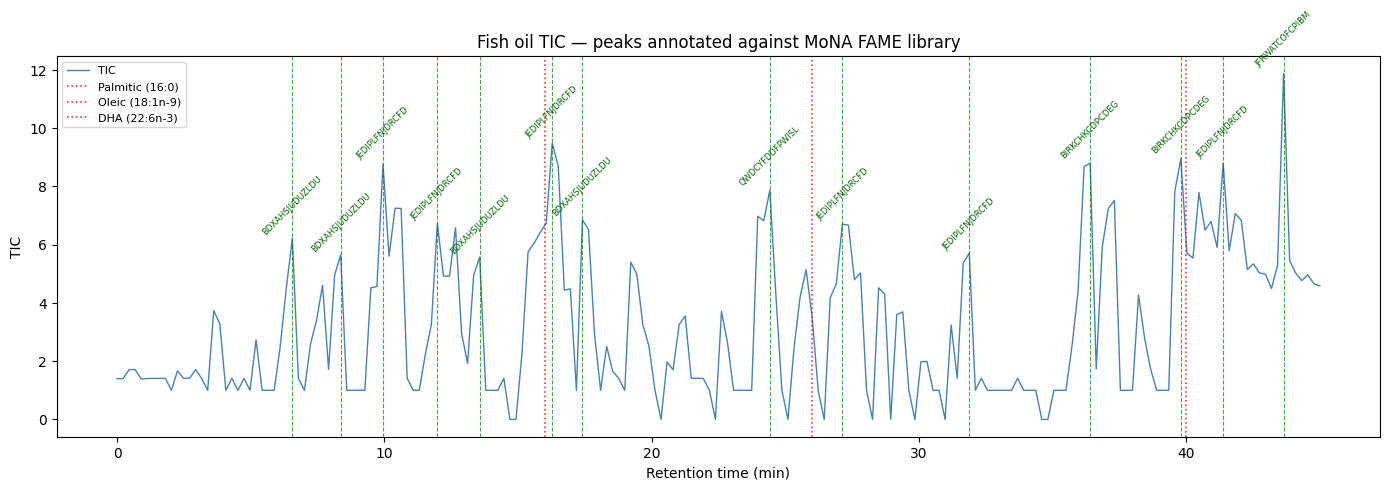

In [14]:
# Visualise: overlay identified peaks on TIC with compound annotations
fig, ax = plt.subplots(figsize=(14, 5))
tic = fish_sample.sum(axis=1)
ax.plot(TIME_AXIS, tic, color='steelblue', lw=1, label='TIC')

for d in ids:
    color = 'green' if d['confident'] else 'gray'
    ax.axvline(d['rt_min'], color=color, lw=0.8, ls='--', alpha=0.7)
    if d['confident']:
        tic_val = tic[int(d['rt_min'] / MIN_PER_BIN)]
        ax.text(d['rt_min'], tic_val * 1.02, d['inchikey'][:14],
                fontsize=6, ha='center', color='darkgreen', rotation=45)

for name, rt in LANDMARKS.items():
    ax.axvline(rt, color='red', lw=1.2, ls=':', alpha=0.8, label=name)

ax.set_xlabel('Retention time (min)')
ax.set_ylabel('TIC')
ax.set_title('Fish oil TIC — peaks annotated against MoNA FAME library')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


## 9. Encoder-guided alignment

Replace raw cosine similarity with embeddings from the SimCLR-pretrained encoder.

**Training summary:**
- Stage 1: 150 epochs on 9,553 MoNA EI-MS spectra → general EI-MS features
- Stage 2: 200 epochs on 2,060 chromatogram peaks (fish_oil + mtbls288) → domain adaptation

We swap the encoder into the alignment pipeline and re-run the within-study TIC correlation comparison.

In [15]:
import sys, torch
sys.path.insert(0, '../src')
from encoder import SpectrumEncoder

DEVICE = torch.device('cpu')
CKPT   = '../checkpoints/gcms_simclr.pt'

encoder = SpectrumEncoder().to(DEVICE)
encoder.load_state_dict(torch.load(CKPT, map_location=DEVICE))
encoder.eval()

def encode_spectra(spectra_np):
    """Encode a (N, 1000) numpy array → (N, 128) L2-normalised embeddings."""
    with torch.no_grad():
        t = torch.from_numpy(spectra_np.astype('float32')).to(DEVICE)
        return encoder.encode(t).cpu().numpy()

print(f'Loaded encoder from {CKPT}')
print(f'Parameters: {sum(p.numel() for p in encoder.parameters()):,}')


Loaded encoder from ../checkpoints/gcms_simclr.pt
Parameters: 703,040


In [16]:
from scipy.optimize import linear_sum_assignment
from scipy.interpolate import interp1d

def align_encoded(query_chroma, ref_chroma, sim_threshold=0.6, max_drift_min=6.0):
    """
    Same pipeline as align_to_reference but uses SimCLR embeddings
    instead of raw L2-normalised m/z spectra for the cosine similarity.
    """
    ref_peaks = detect_peaks(ref_chroma)
    q_peaks   = detect_peaks(query_chroma)

    # Raw fingerprints → encoder embeddings
    ref_fps   = extract_fingerprints(ref_chroma, ref_peaks)   # (n_ref, 1000)
    q_fps     = extract_fingerprints(query_chroma, q_peaks)   # (n_q,   1000)
    ref_emb   = encode_spectra(ref_fps)                        # (n_ref, 128)
    q_emb     = encode_spectra(q_fps)                          # (n_q,   128)

    sim = cosine_similarity(q_emb, ref_emb)                   # (n_q, n_ref)

    # Windowed Hungarian matching
    ref_times = TIME_AXIS[ref_peaks]
    q_times   = TIME_AXIS[q_peaks]
    drift_mask = np.abs(q_times[:, None] - ref_times[None, :]) > max_drift_min
    sim_c = sim.copy()
    sim_c[drift_mask] = -1.0

    row_ind, col_ind = linear_sum_assignment(-sim_c)
    matched_sim = sim[row_ind, col_ind]
    keep = (matched_sim >= sim_threshold) & (~drift_mask[row_ind, col_ind])
    row_ind, col_ind = row_ind[keep], col_ind[keep]

    if len(row_ind) < 2:
        return query_chroma.sum(axis=1), None, np.array([]), np.array([])

    order = np.argsort(col_ind)
    row_ind, col_ind = row_ind[order], col_ind[order]
    ref_anchors = TIME_AXIS[ref_peaks[col_ind]]
    q_anchors   = TIME_AXIS[q_peaks[row_ind]]

    # Monotonicity
    monotone = [0]
    for i in range(1, len(q_anchors)):
        if q_anchors[i] > q_anchors[monotone[-1]]:
            monotone.append(i)
    ref_anchors = ref_anchors[monotone]
    q_anchors   = q_anchors[monotone]

    ref_full = np.concatenate([[0], ref_anchors, [RUN_DURATION_MIN]])
    q_full   = np.concatenate([[0], q_anchors,   [RUN_DURATION_MIN]])
    warp_fn  = interp1d(ref_full, q_full, kind='linear',
                        bounds_error=False, fill_value='extrapolate')
    query_times_on_ref = warp_fn(TIME_AXIS)
    query_tic  = query_chroma.sum(axis=1)
    resample   = interp1d(TIME_AXIS, query_tic, bounds_error=False, fill_value=0.0)
    warped_tic = resample(query_times_on_ref)
    return warped_tic, warp_fn, ref_anchors, q_anchors


Within-study TIC correlation (fish_oil):
  Unaligned:      0.564
  Raw cosine:     0.664
  SimCLR encoder: 0.677


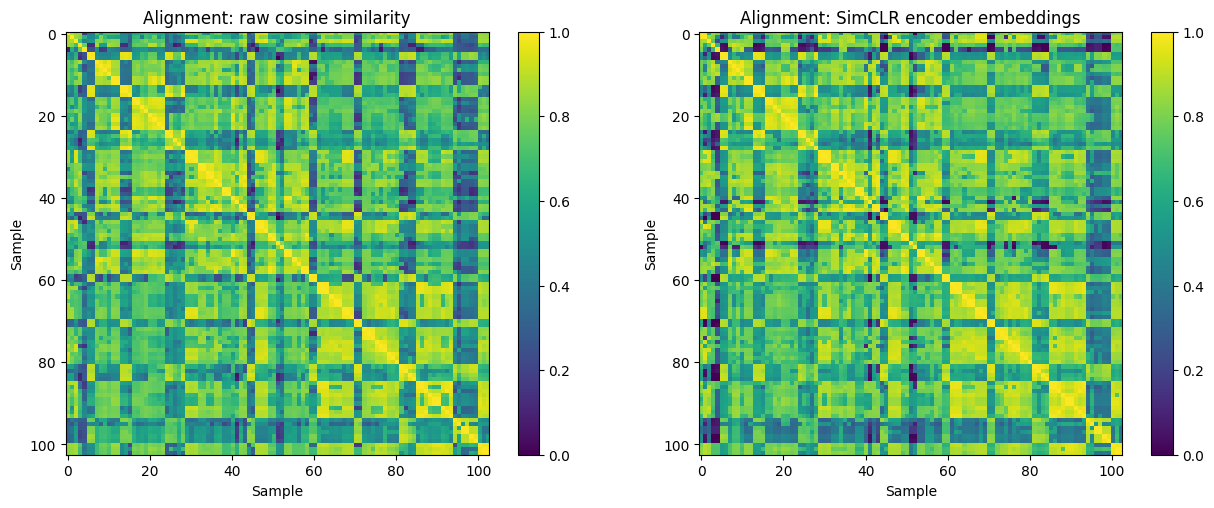

In [17]:
# Within-study comparison: raw cosine vs encoder embeddings
n = len(all_chromas)
tics = [c.sum(axis=1) for c in all_chromas]

corr_raw    = np.zeros((n, n))   # from section 6
corr_enc    = np.zeros((n, n))

for i in range(n):
    for j in range(n):
        corr_raw[i, j] = np.corrcoef(tics[i],
            align_to_reference(all_chromas[j], all_chromas[i])[0])[0, 1]
        corr_enc[i, j] = np.corrcoef(tics[i],
            align_encoded(all_chromas[j], all_chromas[i])[0])[0, 1]

mask = ~np.eye(n, dtype=bool)
print('Within-study TIC correlation (fish_oil):')
print(f'  Unaligned:      {np.array([np.corrcoef(tics[i], tics[j])[0,1] for i in range(n) for j in range(n) if i!=j]).mean():.3f}')
print(f'  Raw cosine:     {corr_raw[mask].mean():.3f}')
print(f'  SimCLR encoder: {corr_enc[mask].mean():.3f}')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, mat, title in zip(axes,
    [corr_raw, corr_enc],
    ['Alignment: raw cosine similarity', 'Alignment: SimCLR encoder embeddings']):
    im = ax.imshow(mat, vmin=0, vmax=1, cmap='viridis')
    ax.set_title(title)
    ax.set_xlabel('Sample'); ax.set_ylabel('Sample')
    plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()


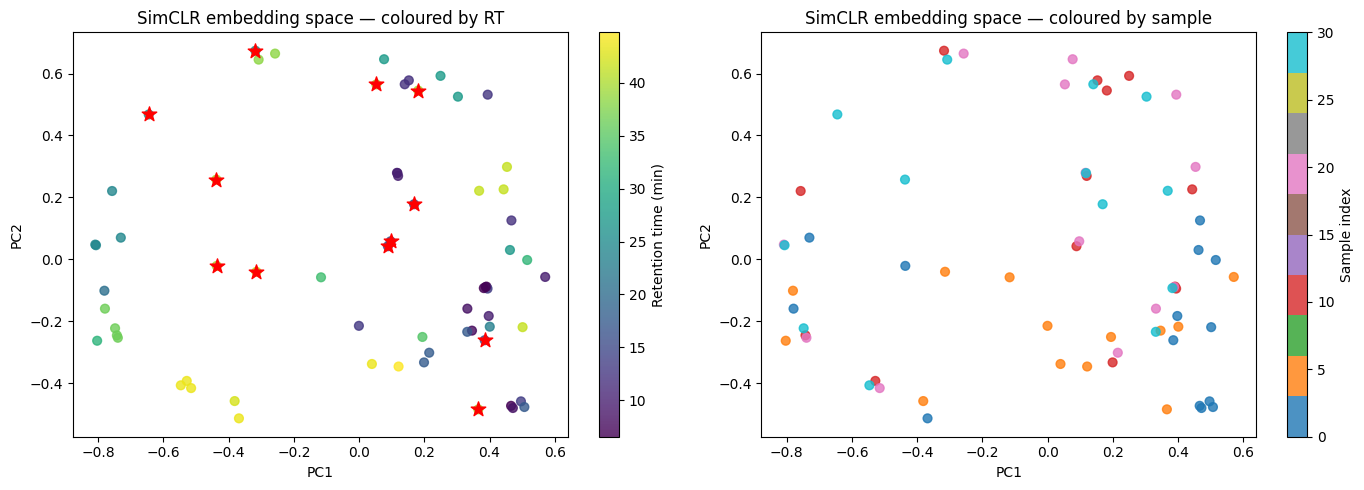

PCA explained variance: 49.0%


In [18]:
# Visualise embedding space: do peaks cluster by compound?
from sklearn.decomposition import PCA

# Extract embeddings for all peaks in the reference sample
ref_chroma = all_chromas[0]
ref_peaks_idx = detect_peaks(ref_chroma)
ref_fps = extract_fingerprints(ref_chroma, ref_peaks_idx)
ref_emb = encode_spectra(ref_fps)

# Also get embeddings for same peaks across several other samples
sample_indices = [0, 5, 10, 20, 30]
all_embs, all_rts, all_sample = [], [], []
for si in sample_indices:
    ch = all_chromas[si]
    pk = detect_peaks(ch)
    fp = extract_fingerprints(ch, pk)
    em = encode_spectra(fp)
    all_embs.append(em)
    all_rts.extend(TIME_AXIS[pk].tolist())
    all_sample.extend([si] * len(pk))

all_embs = np.concatenate(all_embs, axis=0)
all_rts  = np.array(all_rts)
all_sample = np.array(all_sample)

pca = PCA(n_components=2)
coords = pca.fit_transform(all_embs)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sc = axes[0].scatter(coords[:, 0], coords[:, 1], c=all_rts, cmap='viridis', s=40, alpha=0.8)
plt.colorbar(sc, ax=axes[0], label='Retention time (min)')
axes[0].set_title('SimCLR embedding space — coloured by RT')
axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2')

sc = axes[1].scatter(coords[:, 0], coords[:, 1], c=all_sample, cmap='tab10', s=40, alpha=0.8)
plt.colorbar(sc, ax=axes[1], label='Sample index')
axes[1].set_title('SimCLR embedding space — coloured by sample')
axes[1].set_xlabel('PC1'); axes[1].set_ylabel('PC2')

for rt, name in LANDMARKS.items():
    # Find nearest peaks to landmark RT
    dists = np.abs(all_rts - name)
    near  = dists < 1.0
    if near.any():
        axes[0].scatter(coords[near, 0], coords[near, 1],
                        s=120, marker='*', color='red', zorder=5, label=rt)

plt.tight_layout()
plt.show()
print(f'PCA explained variance: {pca.explained_variance_ratio_[:2].sum():.1%}')


## 10. Cross-study alignment: widening the search window

The ±6 min window found zero anchors between fish_oil and mtbls288. Here we sweep
the window from 4 to 20 min and compare raw cosine vs SimCLR encoder embeddings.
The goal is to find the smallest window at which valid anchors appear, and whether
the encoder embeddings improve anchor quality over raw cosine.

In [19]:
def align_cross_study(query_chroma, ref_chroma, max_drift_min=10.0,
                      sim_threshold=0.5, use_encoder=False):
    """
    Alignment with configurable window and optionally encoder embeddings.
    Returns (warped_tic, n_anchors, mean_anchor_sim).
    """
    ref_peaks = detect_peaks(ref_chroma)
    q_peaks   = detect_peaks(query_chroma)

    ref_fps = extract_fingerprints(ref_chroma, ref_peaks)
    q_fps   = extract_fingerprints(query_chroma, q_peaks)

    if use_encoder:
        ref_rep = encode_spectra(ref_fps)
        q_rep   = encode_spectra(q_fps)
    else:
        ref_rep = ref_fps
        q_rep   = q_fps

    sim = cosine_similarity(q_rep, ref_rep)

    ref_times  = TIME_AXIS[ref_peaks]
    q_times    = TIME_AXIS[q_peaks]
    drift_mask = np.abs(q_times[:, None] - ref_times[None, :]) > max_drift_min
    sim_c = sim.copy(); sim_c[drift_mask] = -1.0

    row_ind, col_ind = linear_sum_assignment(-sim_c)
    matched_sim = sim[row_ind, col_ind]
    keep = (matched_sim >= sim_threshold) & (~drift_mask[row_ind, col_ind])
    row_ind, col_ind = row_ind[keep], col_ind[keep]

    if len(row_ind) < 2:
        return query_chroma.sum(axis=1), 0, 0.0

    order = np.argsort(col_ind)
    row_ind, col_ind = row_ind[order], col_ind[order]
    ref_anch = TIME_AXIS[ref_peaks[col_ind]]
    q_anch   = TIME_AXIS[q_peaks[row_ind]]

    monotone = [0]
    for i in range(1, len(q_anch)):
        if q_anch[i] > q_anch[monotone[-1]]:
            monotone.append(i)
    ref_anch = ref_anch[monotone]; q_anch = q_anch[monotone]

    ref_full = np.concatenate([[0], ref_anch, [RUN_DURATION_MIN]])
    q_full   = np.concatenate([[0], q_anch,   [RUN_DURATION_MIN]])
    warp_fn  = interp1d(ref_full, q_full, kind='linear',
                        bounds_error=False, fill_value='extrapolate')
    q_tic      = query_chroma.sum(axis=1)
    resample   = interp1d(TIME_AXIS, q_tic, bounds_error=False, fill_value=0.0)
    warped_tic = resample(warp_fn(TIME_AXIS))

    n_anchors  = len(ref_anch)
    mean_sim   = float(matched_sim[keep][monotone].mean()) if n_anchors > 0 else 0.0
    return warped_tic, n_anchors, mean_sim


In [20]:
# Window sweep: test a handful of fish_oil ↔ mtbls288 pairs
windows = [4, 6, 8, 10, 12, 15, 20]

# Use a small subset for speed: 10 fish × 10 mtbls288
fish_sub  = all_fish[:10]
m288_sub  = all_m288[:10]
fish_tics = [c.sum(axis=1) for c in fish_sub]
m288_tics = [c.sum(axis=1) for c in m288_sub]

results = {w: {'raw': [], 'enc': []} for w in windows}

for w in windows:
    for fc, ft in zip(fish_sub, fish_tics):
        for mc, mt in zip(m288_sub, m288_tics):
            # Unaligned baseline
            base = np.corrcoef(ft, mt)[0, 1]
            # Raw cosine
            warped_r, n_r, _ = align_cross_study(mc, fc, max_drift_min=w,
                                                  sim_threshold=0.5, use_encoder=False)
            corr_r = np.corrcoef(ft, warped_r)[0, 1]
            results[w]['raw'].append((base, corr_r, n_r))
            # Encoder
            warped_e, n_e, _ = align_cross_study(mc, fc, max_drift_min=w,
                                                  sim_threshold=0.5, use_encoder=True)
            corr_e = np.corrcoef(ft, warped_e)[0, 1]
            results[w]['enc'].append((base, corr_e, n_e))

# Summarise
print(f"{'Window':>8}  {'Raw corr':>10}  {'Enc corr':>10}  {'Raw anchors':>12}  {'Enc anchors':>12}")
print("-" * 60)
unaligned_mean = np.mean([r[0] for r in results[4]['raw']])
print(f"{'unaligned':>8}  {unaligned_mean:>10.3f}")
for w in windows:
    raw_corrs   = [r[1] for r in results[w]['raw']]
    enc_corrs   = [r[1] for r in results[w]['enc']]
    raw_anchors = [r[2] for r in results[w]['raw']]
    enc_anchors = [r[2] for r in results[w]['enc']]
    print(f"{w:>8}  {np.mean(raw_corrs):>10.3f}  {np.mean(enc_corrs):>10.3f}"
          f"  {np.mean(raw_anchors):>12.1f}  {np.mean(enc_anchors):>12.1f}")


  Window    Raw corr    Enc corr   Raw anchors   Enc anchors
------------------------------------------------------------
unaligned       0.161
       4       0.161       0.164           0.0           0.1
       6       0.162       0.162           0.0           0.1
       8       0.169       0.162           0.1           0.1
      10       0.168       0.164           0.1           0.1
      12       0.168       0.164           0.1           0.1
      15       0.165       0.162           0.1           0.1
      20       0.165       0.162           0.1           0.1


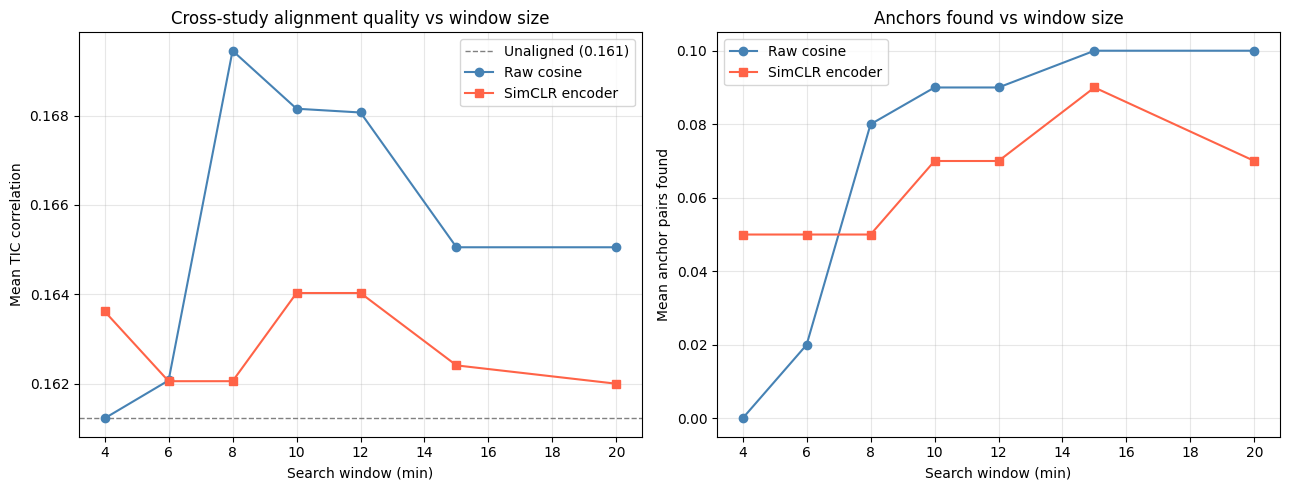

In [21]:
# Plot: correlation improvement vs window size
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

raw_means = [np.mean([r[1] for r in results[w]['raw']]) for w in windows]
enc_means = [np.mean([r[1] for r in results[w]['enc']]) for w in windows]
raw_anch  = [np.mean([r[2] for r in results[w]['raw']]) for w in windows]
enc_anch  = [np.mean([r[2] for r in results[w]['enc']]) for w in windows]

ax = axes[0]
ax.axhline(unaligned_mean, color='gray', lw=1, ls='--', label=f'Unaligned ({unaligned_mean:.3f})')
ax.plot(windows, raw_means, 'o-', color='steelblue', label='Raw cosine')
ax.plot(windows, enc_means, 's-', color='tomato',    label='SimCLR encoder')
ax.set_xlabel('Search window (min)')
ax.set_ylabel('Mean TIC correlation')
ax.set_title('Cross-study alignment quality vs window size')
ax.legend(); ax.grid(alpha=0.3)

ax = axes[1]
ax.plot(windows, raw_anch, 'o-', color='steelblue', label='Raw cosine')
ax.plot(windows, enc_anch, 's-', color='tomato',    label='SimCLR encoder')
ax.set_xlabel('Search window (min)')
ax.set_ylabel('Mean anchor pairs found')
ax.set_title('Anchors found vs window size')
ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


Best window for encoder: 10 min



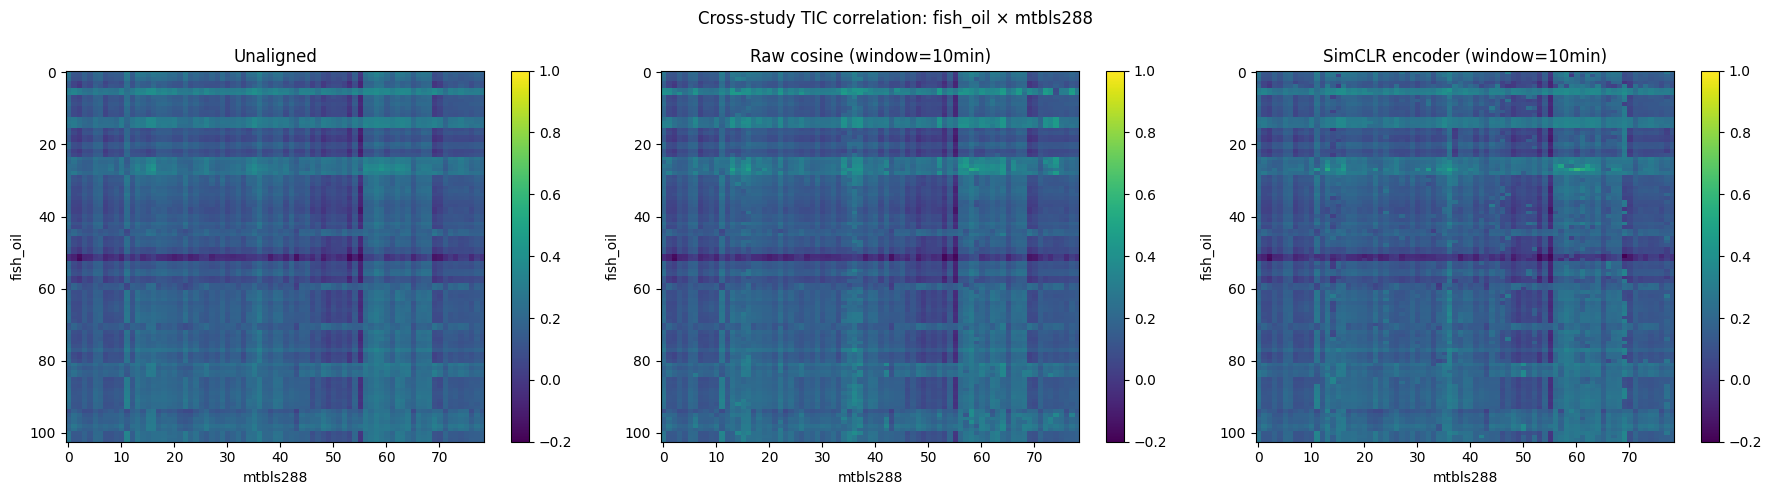

Cross-study mean TIC correlation:
  Unaligned:      0.161
  Raw cosine:     0.165
  SimCLR encoder: 0.165


In [22]:
# Best window: full cross-study matrix with encoder
best_window = windows[np.argmax(enc_means)]
print(f'Best window for encoder: {best_window} min')
print()

n_fish = len(all_fish)
n_m288 = len(all_m288)

cross_enc = np.zeros((n_fish, n_m288))
cross_raw = np.zeros((n_fish, n_m288))
cross_base= np.zeros((n_fish, n_m288))

fish_tics_all = [c.sum(axis=1) for c in all_fish]
m288_tics_all = [c.sum(axis=1) for c in all_m288]

for i, (fc, ft) in enumerate(zip(all_fish, fish_tics_all)):
    for j, (mc, mt) in enumerate(zip(all_m288, m288_tics_all)):
        cross_base[i, j] = np.corrcoef(ft, mt)[0, 1]
        warped_r, _, _ = align_cross_study(mc, fc, max_drift_min=best_window,
                                           sim_threshold=0.5, use_encoder=False)
        cross_raw[i, j]  = np.corrcoef(ft, warped_r)[0, 1]
        warped_e, _, _ = align_cross_study(mc, fc, max_drift_min=best_window,
                                           sim_threshold=0.5, use_encoder=True)
        cross_enc[i, j]  = np.corrcoef(ft, warped_e)[0, 1]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, mat, title in zip(axes,
    [cross_base, cross_raw, cross_enc],
    ['Unaligned', f'Raw cosine (window={best_window}min)',
     f'SimCLR encoder (window={best_window}min)']):
    im = ax.imshow(mat, vmin=-0.2, vmax=1, cmap='viridis', aspect='auto')
    ax.set_title(title); ax.set_xlabel('mtbls288'); ax.set_ylabel('fish_oil')
    plt.colorbar(im, ax=ax)
plt.suptitle('Cross-study TIC correlation: fish_oil × mtbls288', fontsize=12)
plt.tight_layout()
plt.show()

print('Cross-study mean TIC correlation:')
print(f'  Unaligned:      {cross_base.mean():.3f}')
print(f'  Raw cosine:     {cross_raw.mean():.3f}')
print(f'  SimCLR encoder: {cross_enc.mean():.3f}')


## 11. Drift-augmented encoder evaluation

The drift encoder was trained with a different pretraining signal:
positive pairs are the **same compound before and after a random time warp**
(up to ±9 min / 40 bins). This directly teaches the encoder that the same
compound should have the same embedding regardless of when it elutes —
the invariance needed for cross-lab alignment.

We compare all three methods across both within-study and cross-study alignment.

In [23]:
# Load drift encoder
drift_encoder = SpectrumEncoder().to(DEVICE)
drift_encoder.load_state_dict(torch.load('../checkpoints/drift_simclr.pt',
                                          map_location=DEVICE))
drift_encoder.eval()

def encode_drift(spectra_np):
    with torch.no_grad():
        t = torch.from_numpy(spectra_np.astype('float32')).to(DEVICE)
        return drift_encoder.encode(t).cpu().numpy()

print('Drift encoder loaded.')


Drift encoder loaded.


In [24]:
def align_with(query_chroma, ref_chroma, encode_fn=None,
               sim_threshold=0.5, max_drift_min=6.0):
    """
    Unified alignment function. encode_fn=None uses raw cosine similarity.
    """
    ref_pks = detect_peaks(ref_chroma)
    q_pks   = detect_peaks(query_chroma)
    ref_fps = extract_fingerprints(ref_chroma, ref_pks)
    q_fps   = extract_fingerprints(query_chroma, q_pks)

    ref_rep = encode_fn(ref_fps) if encode_fn else ref_fps
    q_rep   = encode_fn(q_fps)   if encode_fn else q_fps

    sim = cosine_similarity(q_rep, ref_rep)
    ref_t = TIME_AXIS[ref_pks]; q_t = TIME_AXIS[q_pks]
    drift_mask = np.abs(q_t[:, None] - ref_t[None, :]) > max_drift_min
    sim_c = sim.copy(); sim_c[drift_mask] = -1.0

    row_ind, col_ind = linear_sum_assignment(-sim_c)
    ms = sim[row_ind, col_ind]
    keep = (ms >= sim_threshold) & ~drift_mask[row_ind, col_ind]
    row_ind, col_ind = row_ind[keep], col_ind[keep]

    if len(row_ind) < 2:
        return query_chroma.sum(axis=1), 0

    order = np.argsort(col_ind)
    row_ind, col_ind = row_ind[order], col_ind[order]
    ra = TIME_AXIS[ref_pks[col_ind]]; qa = TIME_AXIS[q_pks[row_ind]]

    mono = [0]
    for i in range(1, len(qa)):
        if qa[i] > qa[mono[-1]]: mono.append(i)
    ra, qa = ra[mono], qa[mono]

    rf = np.concatenate([[0], ra, [RUN_DURATION_MIN]])
    qf = np.concatenate([[0], qa, [RUN_DURATION_MIN]])
    warp = interp1d(rf, qf, kind='linear', bounds_error=False, fill_value='extrapolate')
    q_tic = query_chroma.sum(axis=1)
    warped = interp1d(TIME_AXIS, q_tic, bounds_error=False,
                      fill_value=0.0)(warp(TIME_AXIS))
    return warped, len(ra)


In [25]:
# ── Within-study: fish_oil (103 × 103) ──────────────────────────────────
methods = {
    'Raw cosine':     None,
    'SimCLR encoder': encode_spectra,
    'Drift encoder':  encode_drift,
}

n = len(all_chromas)
tics_fish = [c.sum(axis=1) for c in all_chromas]
mask = ~np.eye(n, dtype=bool)

within_corrs = {}
for name, enc_fn in methods.items():
    mat = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            warped, _ = align_with(all_chromas[j], all_chromas[i],
                                   encode_fn=enc_fn, max_drift_min=6.0)
            mat[i, j] = np.corrcoef(tics_fish[i], warped)[0, 1]
    within_corrs[name] = mat
    print(f'Within-study  {name:20s}: {mat[mask].mean():.3f}')

unaligned_w = np.mean([np.corrcoef(tics_fish[i], tics_fish[j])[0,1]
                        for i in range(n) for j in range(n) if i != j])
print(f'Within-study  {"Unaligned":20s}: {unaligned_w:.3f}')


Within-study  Raw cosine          : 0.662


Within-study  SimCLR encoder      : 0.668


Within-study  Drift encoder       : 0.599
Within-study  Unaligned           : 0.564


In [26]:
# ── Cross-study: fish_oil × mtbls288 ─────────────────────────────────────
nf, nm = len(all_fish), len(all_m288)
tics_m = [c.sum(axis=1) for c in all_m288]

cross_corrs = {}
for name, enc_fn in methods.items():
    mat = np.zeros((nf, nm))
    for i, (fc, ft) in enumerate(zip(all_fish, tics_fish)):
        for j, (mc, mt) in enumerate(zip(all_m288, tics_m)):
            warped, _ = align_with(mc, fc, encode_fn=enc_fn, max_drift_min=15.0)
            mat[i, j] = np.corrcoef(ft, warped)[0, 1]
    cross_corrs[name] = mat
    print(f'Cross-study   {name:20s}: {mat.mean():.3f}')

unaligned_c = np.mean([np.corrcoef(tics_fish[i], tics_m[j])[0,1]
                        for i in range(nf) for j in range(nm)])
print(f'Cross-study   {"Unaligned":20s}: {unaligned_c:.3f}')


Cross-study   Raw cosine          : 0.162


Cross-study   SimCLR encoder      : 0.162


Cross-study   Drift encoder       : 0.162
Cross-study   Unaligned           : 0.161


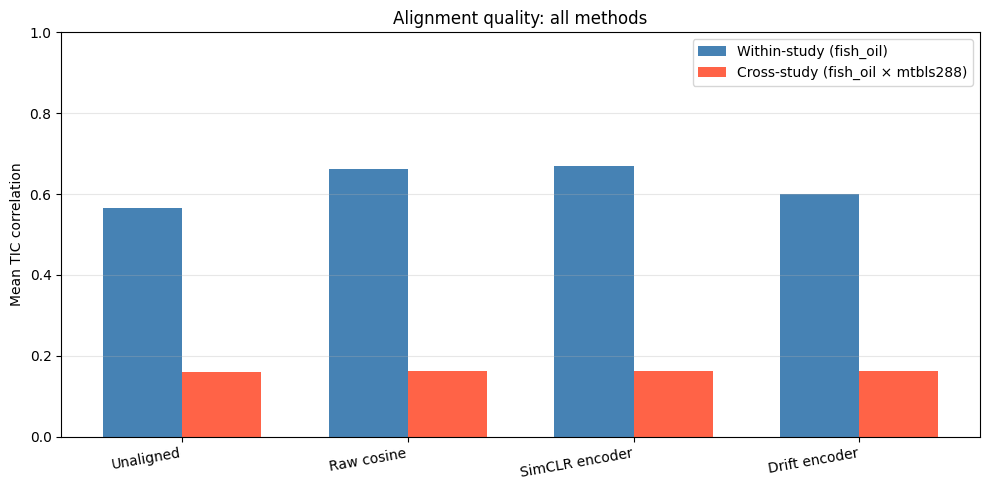

In [27]:
# Summary bar chart
labels  = ['Unaligned'] + list(methods.keys())
within  = [unaligned_w] + [within_corrs[k][mask].mean() for k in methods]
cross   = [unaligned_c] + [cross_corrs[k].mean()        for k in methods]

x = np.arange(len(labels))
w = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - w/2, within, w, label='Within-study (fish_oil)', color='steelblue')
ax.bar(x + w/2, cross,  w, label='Cross-study (fish_oil × mtbls288)', color='tomato')
ax.set_xticks(x); ax.set_xticklabels(labels, rotation=10, ha='right')
ax.set_ylabel('Mean TIC correlation')
ax.set_title('Alignment quality: all methods')
ax.legend(); ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()
